In [23]:
# import rqdatac
# rqdatac.init()

In [24]:
# all_codes = rqdatac.all_instruments(type='CS', market='cn', date='2025-11-14')
# order_book_ids = all_codes['order_book_id']


In [25]:
# turnover1 = rqdatac.get_turnover_rate(order_book_ids, start_date='2000-01-01', end_date='2019-12-31', fields='today',expect_df=True,market='cn')
# turnover1.to_csv('turnover1.csv')

In [26]:
# turnover1.tail()

In [27]:
# turnover2 = rqdatac.get_turnover_rate(order_book_ids, start_date='2020-01-01', end_date='2025-11-1', fields='today',expect_df=True,market='cn')

In [28]:
# turnover2.to_csv('turnover2.csv')


In [29]:
# turnover2.tail()

## turnover - abnormal turnover

In [30]:
import pandas as pd
turnover2 = pd.read_csv('turnover2.csv')
turnover2.tail()

,order_book_id,tradedate,today
6476069,689009.XSHG,2025-10-27,5.9727
6476070,689009.XSHG,2025-10-28,2.7107
6476071,689009.XSHG,2025-10-29,1.9262
6476072,689009.XSHG,2025-10-30,2.1032
6476073,689009.XSHG,2025-10-31,1.5746


In [31]:
turnover1 = pd.read_csv('turnover1.csv')
turnover1.tail()

,order_book_id,tradedate,today
8954995,688399.XSHG,2019-12-25,10.9309
8954996,688399.XSHG,2019-12-26,12.7043
8954997,688399.XSHG,2019-12-27,18.2465
8954998,688399.XSHG,2019-12-30,9.1833
8954999,688399.XSHG,2019-12-31,13.8996


In [32]:
turnover = pd.concat([turnover1, turnover2], axis=0, ignore_index=True)
turnover = turnover.sort_values(
    by=["order_book_id", "tradedate"],  # 排序键
    ascending=[True, True]              # 都升序，按需改成 False
).reset_index(drop=True)                # 重置索引（可选）
turnover.tail()

,order_book_id,tradedate,today
15431069,689009.XSHG,2025-10-27,5.9727
15431070,689009.XSHG,2025-10-28,2.7107
15431071,689009.XSHG,2025-10-29,1.9262
15431072,689009.XSHG,2025-10-30,2.1032
15431073,689009.XSHG,2025-10-31,1.5746


In [33]:
import numpy as np

# 确保日期类型正确
turnover['tradedate'] = pd.to_datetime(turnover['tradedate'])

# 以股票为组，计算 20 日 & 250 日平均日换手率
grouped = turnover.groupby('order_book_id', group_keys=False)

turnover['to_20d'] = grouped['today'].apply(
    lambda s: s.rolling(window=20, min_periods=20).mean()
)
turnover['to_250d'] = grouped['today'].apply(
    lambda s: s.rolling(window=250, min_periods=250).mean()
)

# 日度 abnormal turnover = 过去 20 日平均 / 过去 250 日平均
turnover['abturn'] = turnover['to_20d'] / turnover['to_250d']

# 标记月份
turnover['month'] = turnover['tradedate'].dt.to_period('M')

# 只保留已经有 abturn 的行
tmp = turnover.dropna(subset=['abturn']).copy()

# 对于每个股票-月份，取该月最后一个交易日那条记录
tmp = tmp.sort_values(['order_book_id', 'tradedate'])
month_abturn = (
    tmp.groupby(['order_book_id', 'month'], as_index=False)
       .tail(1)   # 每组最后一行 = 月末交易日
       [['order_book_id', 'month', 'tradedate', 'abturn']]
)



In [34]:
month_abturn.tail()

,order_book_id,month,tradedate,abturn
15430990,689009.XSHG,2025-06,2025-06-30,0.842386
15431013,689009.XSHG,2025-07,2025-07-31,0.859039
15431034,689009.XSHG,2025-08,2025-08-29,1.833201
15431056,689009.XSHG,2025-09,2025-09-30,1.385599
15431073,689009.XSHG,2025-10,2025-10-31,1.167389


## earning

In [35]:
earning2 = pd.read_excel('FI_T2.xlsx',skiprows=[1,2])
earning2.head()

c:\Users\lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Stkcd,ShortName,Accper,F020102
0,1,S 深发展A,2007-03-31,5.323638e+08
1,1,深发展A,2007-06-30,1.117056e+09
2,1,深发展A,2007-09-30,1.867054e+09
3,1,深发展A,2007-12-31,2.607545e+09
4,1,深发展A,2008-03-31,1.001924e+09


In [36]:
earning1 = pd.read_excel('FS_Comins.xlsx',skiprows=[1,2])
earning1.head()

c:\Users\lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Stkcd,ShortName,Accper,Typrep,B002000101
0,1,深发展A,2000-01-01,A,223539210.0
1,1,深发展A,2000-06-30,A,177952845.0
2,1,深发展A,2000-12-31,A,506551785.0
3,1,深发展A,2001-01-01,A,462975563.0
4,1,深发展A,2001-06-30,A,223211685.0


In [37]:
import pandas as pd

earning1['Accper'] = pd.to_datetime(earning1['Accper'])

# 只保留标准季末：3/31, 6/30, 9/30, 12/31
quarter_ends = {(3, 31), (6, 30), (9, 30), (12, 31)}

mask = earning1['Accper'].apply(lambda d: (d.month, d.day) in quarter_ends)

earning1 = earning1[mask]
earning1 = earning1[earning1['Typrep']=='A']
earning1 = earning1[['Stkcd','ShortName','Accper','B002000101']]
earning1 = earning1.rename(columns={'B002000101':'earning'})

earning1.head()

,Stkcd,ShortName,Accper,earning
1,1,深发展A,2000-06-30,177952845.0
2,1,深发展A,2000-12-31,506551785.0
4,1,深发展A,2001-06-30,223211685.0
5,1,深发展A,2001-12-31,402360428.0
7,1,深发展A,2002-03-31,183951144.0


In [38]:

earning2 = earning2.rename(columns={'F020102':'earning'})
earning2.head()


,Stkcd,ShortName,Accper,earning
0,1,S 深发展A,2007-03-31,5.323638e+08
1,1,深发展A,2007-06-30,1.117056e+09
2,1,深发展A,2007-09-30,1.867054e+09
3,1,深发展A,2007-12-31,2.607545e+09
4,1,深发展A,2008-03-31,1.001924e+09


In [39]:
earning = pd.concat([earning1,earning2], axis=0, ignore_index=True)
#注意earning1有缺失

In [40]:
earning.head()

,Stkcd,ShortName,Accper,earning
0,1,深发展A,2000-06-30 00:00:00,177952845.0
1,1,深发展A,2000-12-31 00:00:00,506551785.0
2,1,深发展A,2001-06-30 00:00:00,223211685.0
3,1,深发展A,2001-12-31 00:00:00,402360428.0
4,1,深发展A,2002-03-31 00:00:00,183951144.0


In [41]:
Rept = pd.read_csv('IAR_Rept.csv')
Rept.head()

,Stkcd,Stknme,Reptyp,Accper,Annodt
0,1,深发展A,2,2000-06-30,2000-07-26
1,1,深发展A,4,2000-12-31,2001-04-14
2,1,深发展A,2,2001-06-30,2001-08-21
3,1,深发展A,4,2001-12-31,2002-04-19
4,1,深发展A,1,2002-03-31,2002-04-23


In [42]:
import pandas as pd

# ========= 1) 准备 earn_rep =========
earning['Accper'] = pd.to_datetime(earning['Accper'])
Rept['Accper']    = pd.to_datetime(Rept['Accper'])
Rept['Annodt']    = pd.to_datetime(Rept['Annodt'])

earn_rep = pd.merge(
    Rept[['Stkcd', 'Accper', 'Annodt']],
    earning[['Stkcd', 'Accper', 'earning']],
    on=['Stkcd', 'Accper'],
    how='left'
)

# 注意：一定要先按 Stkcd 和 Annodt 排序
earn_rep = earn_rep.sort_values(['Stkcd', 'Annodt']).reset_index(drop=True)
earn_rep.head()

,Stkcd,Accper,Annodt,earning
0,1,2000-06-30,2000-07-26,177952845.0
1,1,2000-12-31,2001-04-14,506551785.0
2,1,2001-06-30,2001-08-21,223211685.0
3,1,2001-12-31,2002-04-19,402360428.0
4,1,2002-03-31,2002-04-23,183951144.0


In [43]:
import pandas as pd

# ========= 1. 基本清洗：日期 + 季末过滤 =========
earn_rep['Accper'] = pd.to_datetime(earn_rep['Accper'], errors='coerce')
earn_rep['Annodt'] = pd.to_datetime(earn_rep['Annodt'], errors='coerce')

# 只保留正式季末/年末报表：3/31, 6/30, 9/30, 12/31
quarter_ends = {(3, 31), (6, 30), (9, 30), (12, 31)}
earn_rep = earn_rep[
    earn_rep['Accper'].apply(
        lambda d: pd.notna(d) and (d.month, d.day) in quarter_ends
    )
].copy()

# 丢掉没有公告日或没有 earning 的记录
earn_rep = earn_rep.dropna(subset=['Annodt', 'earning']).copy()

# ========= 2. 构造 股票 × 月末 网格 =========
# 用 Annodt 的最小/最大月份生成月度区间
min_month = earn_rep['Annodt'].dt.to_period('M').min()
max_month = earn_rep['Annodt'].dt.to_period('M').max()

# 每个月的月末日期，例如 2000-01-31, 2000-02-29, ...
month_ends = pd.period_range(min_month, max_month, freq='M').to_timestamp('M')

# 所有股票代码
stocks = earn_rep['Stkcd'].dropna().unique()

# 股票 × 月末 的全组合
month_panel = (
    pd.MultiIndex.from_product([stocks, month_ends],
                               names=['Stkcd', 'month_end'])
      .to_frame(index=False)
)

# 排序，方便后面按股票分组做 merge_asof
month_panel = month_panel.sort_values(['Stkcd', 'month_end']).reset_index(drop=True)
earn_sorted = earn_rep.sort_values(['Stkcd', 'Annodt']).reset_index(drop=True)

# ========= 3. 按股票逐只 merge_asof =========
result_list = []

for stk, panel_sub in month_panel.groupby('Stkcd'):
    # 该股票的所有季报记录
    reports = earn_sorted[earn_sorted['Stkcd'] == stk]
    if reports.empty:
        continue  # 这只股票完全没财报，跳过

    # 右表不要再带 Stkcd 列，避免合并后出现 Stkcd_x / Stkcd_y
    reports = reports.drop(columns=['Stkcd'])

    # 对这一只股票：月末、公告日各自按时间排好
    panel_sub = panel_sub.sort_values('month_end')
    reports = reports.sort_values('Annodt')

    merged = pd.merge_asof(
        panel_sub,
        reports,
        left_on='month_end',
        right_on='Annodt',
        direction='backward',   # 选 Annodt <= month_end 且最近的一条
    )

    # 手动把股票代码写回去，保证列名就是 Stkcd
    merged['Stkcd'] = stk

    result_list.append(merged)

# 拼回所有股票
monthly_earn = pd.concat(result_list, ignore_index=True)

# 在第一份公告之前的月份，没有任何 earning，直接丢掉
monthly_earn = monthly_earn.dropna(subset=['earning']).copy()

# ========= 4. 加上 Trdmnt（YYYY-MM） & 整理列顺序 =========
monthly_earn['Trdmnt'] = monthly_earn['month_end'].dt.to_period('M').astype(str)

# 有些列可能存在多余的，比如 index 等，先看看有哪些列
# print(monthly_earn.columns)

# 只保留你关心的几列（存在才会选上）
cols = ['Stkcd', 'Trdmnt', 'month_end', 'Accper', 'Annodt', 'earning']
cols = [c for c in cols if c in monthly_earn.columns]

monthly_earn = monthly_earn[cols].copy()

print(monthly_earn.head())


   Stkcd   Trdmnt  month_end     Accper     Annodt      earning
1      1  2000-07 2000-07-31 2000-06-30 2000-07-26  177952845.0
2      1  2000-08 2000-08-31 2000-06-30 2000-07-26  177952845.0
3      1  2000-09 2000-09-30 2000-06-30 2000-07-26  177952845.0
4      1  2000-10 2000-10-31 2000-06-30 2000-07-26  177952845.0
5      1  2000-11 2000-11-30 2000-06-30 2000-07-26  177952845.0


## risk-free

In [44]:
rfr =pd.read_excel('TRD_Nrrate.xlsx',skiprows=[1,2])
rfr.head()

c:\Users\lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Nrr1,Clsdt,Nrrdata
0,NRI01,2000-01-01,2.25
1,NRI01,2000-01-02,2.25
2,NRI01,2000-01-03,2.25
3,NRI01,2000-01-04,2.25
4,NRI01,2000-01-05,2.25


In [45]:
# 1) 转成日期 & 排序
rfr['Clsdt'] = pd.to_datetime(rfr['Clsdt'])
rfr = rfr.sort_values(['Nrr1', 'Clsdt'])

# 2) 加一个“月份”列
rfr['month'] = rfr['Clsdt'].dt.to_period('M')

# 3) 对每个利率品种 Nrr1、每个月，取该月最后一个交易日那条
rfr_month_end = (
    rfr.groupby(['Nrr1', 'month'], as_index=False)
       .tail(1)[['Nrr1', 'month', 'Clsdt', 'Nrrdata']]
)

# 4) 为后面好 merge，可以把 month 改个名字
rfr_month_end = rfr_month_end.rename(columns={
    'month': 'ym',
    'Clsdt': 'month_end',
    'Nrrdata': 'rf_annual'
})
rfr_month_end['rf_month'] = rfr_month_end['rf_annual'] / 100 / 12
print(rfr_month_end.head())


      Nrr1       ym  month_end  rf_annual  rf_month
30   NRI01  2000-01 2000-01-31       2.25  0.001875
59   NRI01  2000-02 2000-02-29       2.25  0.001875
90   NRI01  2000-03 2000-03-31       2.25  0.001875
120  NRI01  2000-04 2000-04-30       2.25  0.001875
151  NRI01  2000-05 2000-05-31       2.25  0.001875


## monthly return & Market value

In [46]:
mnth =pd.read_excel('TRD_Mnth.xlsx',skiprows=[1,2])
mnth.head()
#Msmvttl	Mretwd 对应 月个股总市值 考虑现金红利再投资的月个股回报率（size return)

,Stkcd,Trdmnt,Mclsprc,Mnshrtrd,Msmvosd,Msmvttl,Mretwd
0,1,2000-01,18.53,178385288,19843822.88,28755726.61,0.061891
1,1,2000-02,18.32,220816880,19618933.36,28429838.73,-0.011333
2,1,2000-03,18.37,362256029,19672478.48,28507431.08,0.002729
3,1,2000-04,19.05,208567616,20400692.17,29562687.10,0.037017
4,1,2000-05,18.00,98004336,19276244.57,27933247.66,-0.055118


In [47]:
mnth = mnth.rename(columns={'Msmvttl':'MV','Mretwd':'monrtn'})
mnth = mnth[['Stkcd','Trdmnt','MV','monrtn']]
mnth.head()

,Stkcd,Trdmnt,MV,monrtn
0,1,2000-01,28755726.61,0.061891
1,1,2000-02,28429838.73,-0.011333
2,1,2000-03,28507431.08,0.002729
3,1,2000-04,29562687.10,0.037017
4,1,2000-05,27933247.66,-0.055118


In [48]:
import pandas as pd

# ========= 1) 处理 month_abturn：对齐 Stkcd / Trdmnt =========
# month_abturn:
# order_book_id  month(Period)  tradedate  abturn

# 1.1 提取 Stkcd（假设股票代码是前6位数，例如 000001.XSHE -> 1）
month_abturn = month_abturn.copy()
month_abturn['Stkcd'] = month_abturn['order_book_id'].str.slice(0, 6).astype(int)

# 1.2 把 month(Period) 转成和其它表一致的 "YYYY-MM" 格式
month_abturn['Trdmnt'] = month_abturn['month'].astype(str)

# 1.3 只保留需要的列
abturn_m = month_abturn[['Stkcd', 'Trdmnt', 'abturn']].copy()

# ========= 2) 处理 rfr_month_end：对齐 Trdmnt =========
# rfr_month_end:
# Nrr1  ym(Period)  month_end  rf_annual  rf_month

rfr_m = rfr_month_end.copy()
rfr_m['Trdmnt'] = rfr_m['ym'].astype(str)

# 只保留 Trdmnt 和 rf_month
rfr_m = rfr_m[['Trdmnt', 'rf_month']].copy()

# ========= 3) monthly_earn 已经有 Stkcd, Trdmnt, earning =========
earn_m = monthly_earn[['Stkcd', 'Trdmnt', 'earning']].copy()

# ========= 4) mnth 作为“主表”，依次 left merge 其它信息 =========
# mnth:
# Stkcd  Trdmnt  MV  monrtn

base = mnth.copy()

# 4.1 合并 earning
base = base.merge(earn_m, on=['Stkcd', 'Trdmnt'], how='left')

# 4.2 合并 abturn
base = base.merge(abturn_m, on=['Stkcd', 'Trdmnt'], how='left')

# 4.3 合并 rf_month（按月份）
base = base.merge(rfr_m, on='Trdmnt', how='left')

# ========= 5) 最终只保留指定列 =========
final = base[['Stkcd', 'Trdmnt', 'abturn', 'earning', 'rf_month', 'MV', 'monrtn']].copy()

print(final.head())


   Stkcd   Trdmnt  abturn  earning  rf_month           MV    monrtn
0      1  2000-01     NaN      NaN  0.001875  28755726.61  0.061891
1      1  2000-02     NaN      NaN  0.001875  28429838.73 -0.011333
2      1  2000-03     NaN      NaN  0.001875  28507431.08  0.002729
3      1  2000-04     NaN      NaN  0.001875  29562687.10  0.037017
4      1  2000-05     NaN      NaN  0.001875  27933247.66 -0.055118


In [49]:
df = final.copy()
df['Stkcd_str'] = df['Stkcd'].astype(int).astype(str).str.zfill(6)
df = df[df['Stkcd_str'].str[:2].isin(['60', '00', '30'])].copy()
df.tail()

,Stkcd,Trdmnt,abturn,earning,rf_month,MV,monrtn,Stkcd_str
773871,605599,2025-06,2.430466,2.768885e+08,0.000792,12716667.03,0.101837,605599
773872,605599,2025-07,0.729072,2.768885e+08,0.000792,11791111.45,-0.072783,605599
773873,605599,2025-08,0.935563,3.955026e+08,0.000792,10850000.31,-0.079815,605599
773874,605599,2025-09,0.731358,3.955026e+08,0.000792,10958889.20,0.010036,605599
773875,605599,2025-10,0.839704,5.851273e+08,0.000792,11215555.88,0.023421,605599


In [50]:
df.to_csv('completedata.csv')

In [51]:
# mkt
# size vmg
# pmo 
# size


In [52]:
# ===============================================
#  LSY (2019) 风格的中国因子构造完整脚本
#  - 数据源：completedata.csv
#  - 结果：MKT, SMB (基于EP), VMG, PMO (+ SMB_TO, SMB_CH4)
#  - 输出：
#       1) Table 3 风格统计表（打印在屏幕）
#       2) 因子相关系数矩阵（打印在屏幕）
#       3) 四个因子的累计收益图
#       4) 因子时序保存为 CH_factors_monthly.csv
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 0. 参数设定 ----------

PATH_TO_CSV = "completedata.csv"   # 改成你的真实路径

# Table 3 使用的样本区间（LSY：2000-01 ~ 2016-12）
SAMPLE_START = pd.Timestamp("2000-01-01")
SAMPLE_END   = pd.Timestamp("2016-12-31")

# ---------- 1. 读取数据 & 预处理 ----------

df = pd.read_csv(PATH_TO_CSV)

# 确保这些列存在：Stkcd, Trdmnt, monrtn, MV, earning, abturn, rf_month
# 若列名不一致，改这里的映射即可。
required_cols = ['Stkcd', 'Trdmnt', 'monrtn', 'MV', 'earning', 'abturn', 'rf_month']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"缺少必要列: {missing}")

# 转日期 & 排序
df['Trdmnt'] = pd.to_datetime(df['Trdmnt'])
df = df.sort_values(['Stkcd', 'Trdmnt'])

# （可选）如果你的数据里有港股 / B股 / 非A股，可以在这里加股票代码筛选
# 例如 Stkcd_str 以 '6','0','3' 开头仅保留 A 股等
# df = df[df['Stkcd_str'].astype(str).str.startswith(('0','3','6'))]

# 1.1 盈利前向填充：模拟“最近一次已披露的盈利”
df['earning_ffill'] = df.groupby('Stkcd')['earning'].ffill()

# 1.2 构造滞后一期的信息（t 月组合使用 t-1 月末信息）
df['MV_lag']      = df.groupby('Stkcd')['MV'].shift(1)
df['abturn_lag']  = df.groupby('Stkcd')['abturn'].shift(1)
df['earning_lag'] = df.groupby('Stkcd')['earning_ffill'].shift(1)

# 1.3 用滞后的盈利和市值计算 EP_lag
df['EP_lag'] = df['earning_lag'] / df['MV_lag']

# ---------- 2. 辅助函数 ----------

def value_weighted_return(sub, weight_col='MV_lag', ret_col='monrtn'):
    """
    对子样本 sub 计算市值加权收益率。
    权重列默认使用上一期市值 MV_lag，收益列使用当期 monrtn。
    """
    sub = sub.dropna(subset=[weight_col, ret_col])
    if sub.empty:
        return np.nan
    w = sub[weight_col].astype(float)
    r = sub[ret_col].astype(float)
    if w.sum() == 0:
        return np.nan
    return np.average(r, weights=w)


def construct_monthly_factors(month_df):
    """
    对单个月份截面构造：
      - MKT
      - SMB_EP  (基于 EP 的 SMB，CH-3 的 SMB)
      - VMG
      - SMB_TO  (基于 turnover 的 SMB)
      - PMO
      - SMB_CH4 (四因子模型的 SMB：0.5*SMB_EP + 0.5*SMB_TO)
    全部使用 lag 后的信息 (MV_lag, EP_lag, abturn_lag) 做分组。
    """

    # 只保留有上一期市值和当期收益的记录
    month_df = month_df.dropna(subset=['MV_lag', 'monrtn'])

    if len(month_df) < 20:
        # 当月样本太少，则全部返回 NaN
        return pd.Series(
            {k: np.nan for k in ['MKT', 'SMB_EP', 'VMG', 'SMB_TO', 'PMO', 'SMB_CH4']}
        )

    # ---- 2.1 剔除最小 30% 股票：按 MV_lag ----
    mv_lag = month_df['MV_lag']
    size_30 = np.nanpercentile(mv_lag, 30)
    universe = month_df[mv_lag >= size_30].copy()

    if len(universe) < 20:
        return pd.Series(
            {k: np.nan for k in ['MKT', 'SMB_EP', 'VMG', 'SMB_TO', 'PMO', 'SMB_CH4']}
        )

    # ---- 2.2 市场因子 MKT：top 70% 宇宙的市值加权收益 - rf ----
    rf_vals = universe['rf_month'].dropna().unique()
    rf = rf_vals[0] if len(rf_vals) > 0 else 0.0
    mkt_ret = value_weighted_return(universe, weight_col='MV_lag', ret_col='monrtn')
    MKT = mkt_ret - rf

    # ---- 2.3 Size 分组：Small / Big（用 MV_lag 的中位数）----
    median_mv = universe['MV_lag'].median()
    universe['SIZE_G'] = np.where(universe['MV_lag'] <= median_mv, 'S', 'B')

    # ---- 2.4 EP 分组：Value / Middle / Growth（用 EP_lag）----

    # 先用 EP_lag > 0 的股票算 30/70 分位点
    pos_mask = universe['EP_lag'] > 0
    ep_pos = universe.loc[pos_mask, 'EP_lag'].dropna()
    if len(ep_pos) >= 3:
        ep_30, ep_70 = np.nanpercentile(ep_pos, [30, 70])
    else:
        # 极端情形下用全体 EP_lag 的分位点
        ep_all = universe['EP_lag'].dropna()
        if len(ep_all) >= 3:
            ep_30, ep_70 = np.nanpercentile(ep_all, [30, 70])
        else:
            ep_30 = ep_70 = np.nan

    def assign_ep_group(ep):
        if pd.isna(ep):
            return np.nan
        if ep <= 0:
            # 负盈利直接归 Growth 组
            return 'G'
        if np.isfinite(ep_30) and ep <= ep_30:
            return 'G'
        if np.isfinite(ep_70) and ep <= ep_70:
            return 'M'
        return 'V'

    universe['EP_G'] = universe['EP_lag'].apply(assign_ep_group)

    # ---- 2.5 Turnover 分组：Low / Mid / High（用 abturn_lag）----

    ab = universe['abturn_lag']
    if ab.notna().sum() >= 3:
        ab_30, ab_70 = np.nanpercentile(ab.dropna(), [30, 70])
    else:
        ab_30 = ab_70 = np.nan

    def assign_to_group(x):
        if pd.isna(x):
            return np.nan
        if np.isfinite(ab_30) and x <= ab_30:
            return 'L'   # low turnover (pessimistic)
        if np.isfinite(ab_70) and x <= ab_70:
            return 'M'
        return 'H'       # high turnover (optimistic)

    universe['TO_G'] = universe['abturn_lag'].apply(assign_to_group)

    # 简化一下加权收益调用
    def vw(mask):
        return value_weighted_return(universe[mask],
                                     weight_col='MV_lag',
                                     ret_col='monrtn')

    # ---------- 2.6 Size × EP：六个组合 ----------
    R_SV = vw((universe['SIZE_G'] == 'S') & (universe['EP_G'] == 'V'))
    R_SM = vw((universe['SIZE_G'] == 'S') & (universe['EP_G'] == 'M'))
    R_SG = vw((universe['SIZE_G'] == 'S') & (universe['EP_G'] == 'G'))
    R_BV = vw((universe['SIZE_G'] == 'B') & (universe['EP_G'] == 'V'))
    R_BM = vw((universe['SIZE_G'] == 'B') & (universe['EP_G'] == 'M'))
    R_BG = vw((universe['SIZE_G'] == 'B') & (universe['EP_G'] == 'G'))

    # 基于 EP 的 SMB（CH-3 的 SMB）
    SMB_EP = (R_SV + R_SM + R_SG) / 3.0 - (R_BV + R_BM + R_BG) / 3.0
    # 价值因子 VMG
    VMG = 0.5 * (R_SV + R_BV) - 0.5 * (R_SG + R_BG)

    # ---------- 2.7 Size × Turnover：六个组合 ----------
    R_SL   = vw((universe['SIZE_G'] == 'S') & (universe['TO_G'] == 'L'))
    R_SM_t = vw((universe['SIZE_G'] == 'S') & (universe['TO_G'] == 'M'))
    R_SH   = vw((universe['SIZE_G'] == 'S') & (universe['TO_G'] == 'H'))
    R_BL   = vw((universe['SIZE_G'] == 'B') & (universe['TO_G'] == 'L'))
    R_BM_t = vw((universe['SIZE_G'] == 'B') & (universe['TO_G'] == 'M'))
    R_BH   = vw((universe['SIZE_G'] == 'B') & (universe['TO_G'] == 'H'))

    # 基于 turnover 的 SMB
    SMB_TO = (R_SL + R_SM_t + R_SH) / 3.0 - (R_BL + R_BM_t + R_BH) / 3.0
    # 情绪因子 PMO：Low minus High（pessimistic minus optimistic）
    PMO = 0.5 * (R_SL + R_BL) - 0.5 * (R_SH + R_BH)

    # ---------- 2.8 CH-4 的 SMB ----------
    SMB_CH4 = 0.5 * SMB_EP + 0.5 * SMB_TO

    return pd.Series({
        'MKT': MKT,
        'SMB_EP': SMB_EP,
        'VMG': VMG,
        'SMB_TO': SMB_TO,
        'PMO': PMO,
        'SMB_CH4': SMB_CH4
    })


# ---------- 3. 按月构造因子时序 ----------

# 对 Trdmnt 分组，每月调用一次构造函数
factors = df.groupby('Trdmnt', group_keys=False).apply(construct_monthly_factors)
factors = factors.sort_index()

# 保存全样本因子
factors.to_csv("CH_factors_monthly.csv")

print("已生成因子并保存到 CH_factors_monthly.csv")
print("前几行预览：")
print(factors.head())
# ---------- 4. 复现 Table 3：2000-01 ~ 2016-12（四因子版本） ----------

sample = factors.loc[
    (factors.index >= SAMPLE_START) & (factors.index <= SAMPLE_END),
    ['MKT', 'SMB_CH4', 'VMG', 'PMO']
]

# 均值、标准差（按月百分数） + t-stat（对均值是否显著不为0）
table4 = pd.DataFrame(index=['Mean', 'Std', 't-stat'],
                      columns=['MKT', 'SMB_CH4', 'VMG', 'PMO'])

# ====== 先用“原始小数收益率”算均值、标准差和 t-stat ======
def factor_stats(series):
    """返回 (mean, std, t) 三个指标，基于小数形式收益率"""
    s = series.dropna()
    N = len(s)
    if N <= 1:
        return np.nan, np.nan, np.nan
    mean = s.mean()
    std = s.std(ddof=1)
    t = mean / (std / np.sqrt(N))
    return mean, std, t

stats_MKT     = factor_stats(sample['MKT'])
stats_SMB_CH4 = factor_stats(sample['SMB_CH4'])
stats_VMG     = factor_stats(sample['VMG'])
stats_PMO     = factor_stats(sample['PMO'])

# ====== 填表：Mean、Std 以“百分数”形式展示，t-stat 直接展示 ======

# MKT
table4.loc['Mean',   'MKT']     = stats_MKT[0] * 100
table4.loc['Std',    'MKT']     = stats_MKT[1] * 100
table4.loc['t-stat', 'MKT']     = stats_MKT[2]

# SMB_CH4
table4.loc['Mean',   'SMB_CH4'] = stats_SMB_CH4[0] * 100
table4.loc['Std',    'SMB_CH4'] = stats_SMB_CH4[1] * 100
table4.loc['t-stat', 'SMB_CH4'] = stats_SMB_CH4[2]

# VMG
table4.loc['Mean',   'VMG']     = stats_VMG[0] * 100
table4.loc['Std',    'VMG']     = stats_VMG[1] * 100
table4.loc['t-stat', 'VMG']     = stats_VMG[2]

# PMO
table4.loc['Mean',   'PMO']     = stats_PMO[0] * 100
table4.loc['Std',    'PMO']     = stats_PMO[1] * 100
table4.loc['t-stat', 'PMO']     = stats_PMO[2]

print("\n===== Table 3 风格统计（四因子版本, % per month）=====")
print(table4)

print("\n===== 四因子相关系数矩阵 (MKT, SMB_CH4, VMG, PMO) =====")
cor = sample.corr()
print(cor)


# 转置table4（行列互换）
table4_transposed = table4.T

# 合并数据：将转置后的table4添加到sample的左侧

result_old = pd.concat([table4_transposed, cor], axis=1)

print("\n===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2016=====")
print(result_old)
# mean std and correlations of factors

已生成因子并保存到 CH_factors_monthly.csv
前几行预览：
                 MKT  SMB_EP  VMG  SMB_TO  PMO  SMB_CH4
Trdmnt                                                 
2000-01-01       NaN     NaN  NaN     NaN  NaN      NaN
2000-02-01  0.113636     NaN  NaN     NaN  NaN      NaN
2000-03-01  0.044109     NaN  NaN     NaN  NaN      NaN
2000-04-01  0.014175     NaN  NaN     NaN  NaN      NaN
2000-05-01  0.024001     NaN  NaN     NaN  NaN      NaN

===== Table 3 风格统计（四因子版本, % per month）=====
             MKT   SMB_CH4       VMG       PMO
Mean    0.599849  0.845556  1.059593  1.069709
Std     8.187019  4.843546  3.802401  3.724871
t-stat  1.043912  2.412656  3.911238  3.968908

===== 四因子相关系数矩阵 (MKT, SMB_CH4, VMG, PMO) =====
              MKT   SMB_CH4       VMG       PMO
MKT      1.000000  0.118522 -0.258383 -0.196269
SMB_CH4  0.118522  1.000000 -0.662259  0.090933
VMG     -0.258383 -0.662259  1.000000 -0.036398
PMO     -0.196269  0.090933 -0.036398  1.000000

===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2016

C:\Users\lenovo\AppData\Local\Temp\ipykernel_29432\48984423.py:208: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  factors = df.groupby('Trdmnt', group_keys=False).apply(construct_monthly_factors)


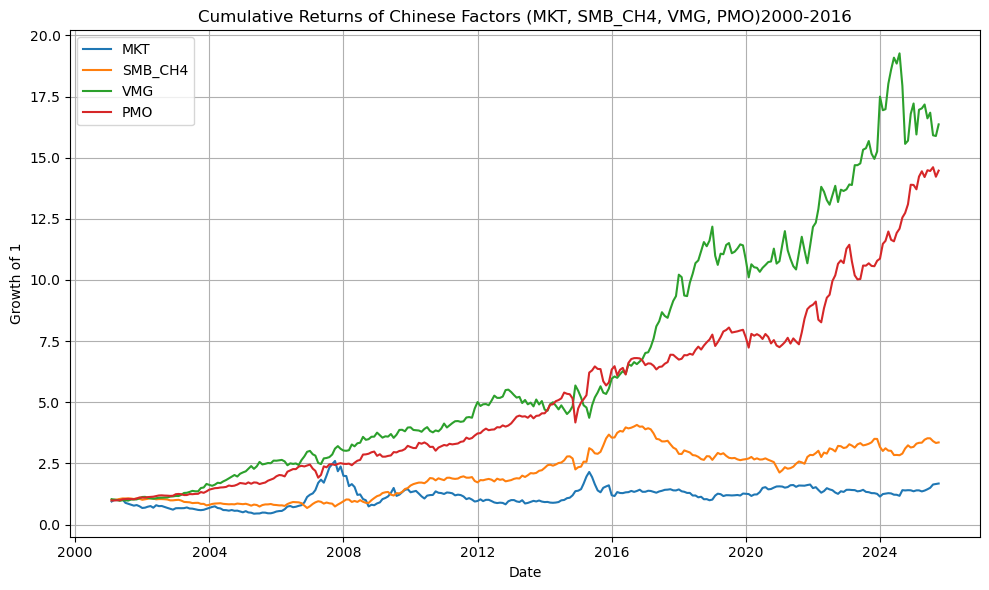

In [54]:

# ---------- 5. 绘制四个因子的累计收益曲线（全样本） ----------

plot_factors = factors[['MKT', 'SMB_CH4', 'VMG', 'PMO']].dropna()

# 累计收益 = ∏(1 + r_t)
cumrets = (1 + plot_factors).cumprod()

plt.figure(figsize=(10, 6))
for col in cumrets.columns:
    plt.plot(cumrets.index, cumrets[col], label=col)

plt.legend()
plt.title("Cumulative Returns of Chinese Factors (MKT, SMB_CH4, VMG, PMO)2000-2016")
plt.xlabel("Date")
plt.ylabel("Growth of 1")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2000-2025

In [55]:
# ===============================================
#  LSY (2019) 风格的中国因子构造完整脚本
#  - 数据源：completedata.csv
#  - 结果：MKT, SMB (基于EP), VMG, PMO (+ SMB_TO, SMB_CH4)
#  - 输出：
#       1) Table 3 风格统计表（打印在屏幕）
#       2) 因子相关系数矩阵（打印在屏幕）
#       3) 四个因子的累计收益图
#       4) 因子时序保存为 CH_factors_monthly.csv
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 0. 参数设定 ----------

PATH_TO_CSV = "completedata.csv"   # 改成你的真实路径

# Table 3 使用的样本区间（LSY：2000-01 ~ 2016-12）
SAMPLE_START = pd.Timestamp("2000-01-01")
SAMPLE_END   = pd.Timestamp("2025-10-31")

# ---------- 1. 读取数据 & 预处理 ----------

df = pd.read_csv(PATH_TO_CSV)

# 确保这些列存在：Stkcd, Trdmnt, monrtn, MV, earning, abturn, rf_month
# 若列名不一致，改这里的映射即可。
required_cols = ['Stkcd', 'Trdmnt', 'monrtn', 'MV', 'earning', 'abturn', 'rf_month']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"缺少必要列: {missing}")

# 转日期 & 排序
df['Trdmnt'] = pd.to_datetime(df['Trdmnt'])
df = df.sort_values(['Stkcd', 'Trdmnt'])

# （可选）如果你的数据里有港股 / B股 / 非A股，可以在这里加股票代码筛选
# 例如 Stkcd_str 以 '6','0','3' 开头仅保留 A 股等
# df = df[df['Stkcd_str'].astype(str).str.startswith(('0','3','6'))]

# 1.1 盈利前向填充：模拟“最近一次已披露的盈利”
df['earning_ffill'] = df.groupby('Stkcd')['earning'].ffill()

# 1.2 构造滞后一期的信息（t 月组合使用 t-1 月末信息）
df['MV_lag']      = df.groupby('Stkcd')['MV'].shift(1)
df['abturn_lag']  = df.groupby('Stkcd')['abturn'].shift(1)
df['earning_lag'] = df.groupby('Stkcd')['earning_ffill'].shift(1)

# 1.3 用滞后的盈利和市值计算 EP_lag
df['EP_lag'] = df['earning_lag'] / df['MV_lag']

# ---------- 2. 辅助函数 ----------

def value_weighted_return(sub, weight_col='MV_lag', ret_col='monrtn'):
    """
    对子样本 sub 计算市值加权收益率。
    权重列默认使用上一期市值 MV_lag，收益列使用当期 monrtn。
    """
    sub = sub.dropna(subset=[weight_col, ret_col])
    if sub.empty:
        return np.nan
    w = sub[weight_col].astype(float)
    r = sub[ret_col].astype(float)
    if w.sum() == 0:
        return np.nan
    return np.average(r, weights=w)


def construct_monthly_factors(month_df):
    """
    对单个月份截面构造：
      - MKT
      - SMB_EP  (基于 EP 的 SMB，CH-3 的 SMB)
      - VMG
      - SMB_TO  (基于 turnover 的 SMB)
      - PMO
      - SMB_CH4 (四因子模型的 SMB：0.5*SMB_EP + 0.5*SMB_TO)
    全部使用 lag 后的信息 (MV_lag, EP_lag, abturn_lag) 做分组。
    """

    # 只保留有上一期市值和当期收益的记录
    month_df = month_df.dropna(subset=['MV_lag', 'monrtn'])

    if len(month_df) < 20:
        # 当月样本太少，则全部返回 NaN
        return pd.Series(
            {k: np.nan for k in ['MKT', 'SMB_EP', 'VMG', 'SMB_TO', 'PMO', 'SMB_CH4']}
        )

    # ---- 2.1 剔除最小 30% 股票：按 MV_lag ----
    mv_lag = month_df['MV_lag']
    size_30 = np.nanpercentile(mv_lag, 30)
    universe = month_df[mv_lag >= size_30].copy()

    if len(universe) < 20:
        return pd.Series(
            {k: np.nan for k in ['MKT', 'SMB_EP', 'VMG', 'SMB_TO', 'PMO', 'SMB_CH4']}
        )

    # ---- 2.2 市场因子 MKT：top 70% 宇宙的市值加权收益 - rf ----
    rf_vals = universe['rf_month'].dropna().unique()
    rf = rf_vals[0] if len(rf_vals) > 0 else 0.0
    mkt_ret = value_weighted_return(universe, weight_col='MV_lag', ret_col='monrtn')
    MKT = mkt_ret - rf

    # ---- 2.3 Size 分组：Small / Big（用 MV_lag 的中位数）----
    median_mv = universe['MV_lag'].median()
    universe['SIZE_G'] = np.where(universe['MV_lag'] <= median_mv, 'S', 'B')

    # ---- 2.4 EP 分组：Value / Middle / Growth（用 EP_lag）----

    # 先用 EP_lag > 0 的股票算 30/70 分位点
    pos_mask = universe['EP_lag'] > 0
    ep_pos = universe.loc[pos_mask, 'EP_lag'].dropna()
    if len(ep_pos) >= 3:
        ep_30, ep_70 = np.nanpercentile(ep_pos, [30, 70])
    else:
        # 极端情形下用全体 EP_lag 的分位点
        ep_all = universe['EP_lag'].dropna()
        if len(ep_all) >= 3:
            ep_30, ep_70 = np.nanpercentile(ep_all, [30, 70])
        else:
            ep_30 = ep_70 = np.nan

    def assign_ep_group(ep):
        if pd.isna(ep):
            return np.nan
        if ep <= 0:
            # 负盈利直接归 Growth 组
            return 'G'
        if np.isfinite(ep_30) and ep <= ep_30:
            return 'G'
        if np.isfinite(ep_70) and ep <= ep_70:
            return 'M'
        return 'V'

    universe['EP_G'] = universe['EP_lag'].apply(assign_ep_group)

    # ---- 2.5 Turnover 分组：Low / Mid / High（用 abturn_lag）----

    ab = universe['abturn_lag']
    if ab.notna().sum() >= 3:
        ab_30, ab_70 = np.nanpercentile(ab.dropna(), [30, 70])
    else:
        ab_30 = ab_70 = np.nan

    def assign_to_group(x):
        if pd.isna(x):
            return np.nan
        if np.isfinite(ab_30) and x <= ab_30:
            return 'L'   # low turnover (pessimistic)
        if np.isfinite(ab_70) and x <= ab_70:
            return 'M'
        return 'H'       # high turnover (optimistic)

    universe['TO_G'] = universe['abturn_lag'].apply(assign_to_group)

    # 简化一下加权收益调用
    def vw(mask):
        return value_weighted_return(universe[mask],
                                     weight_col='MV_lag',
                                     ret_col='monrtn')

    # ---------- 2.6 Size × EP：六个组合 ----------
    R_SV = vw((universe['SIZE_G'] == 'S') & (universe['EP_G'] == 'V'))
    R_SM = vw((universe['SIZE_G'] == 'S') & (universe['EP_G'] == 'M'))
    R_SG = vw((universe['SIZE_G'] == 'S') & (universe['EP_G'] == 'G'))
    R_BV = vw((universe['SIZE_G'] == 'B') & (universe['EP_G'] == 'V'))
    R_BM = vw((universe['SIZE_G'] == 'B') & (universe['EP_G'] == 'M'))
    R_BG = vw((universe['SIZE_G'] == 'B') & (universe['EP_G'] == 'G'))

    # 基于 EP 的 SMB（CH-3 的 SMB）
    SMB_EP = (R_SV + R_SM + R_SG) / 3.0 - (R_BV + R_BM + R_BG) / 3.0
    # 价值因子 VMG
    VMG = 0.5 * (R_SV + R_BV) - 0.5 * (R_SG + R_BG)

    # ---------- 2.7 Size × Turnover：六个组合 ----------
    R_SL   = vw((universe['SIZE_G'] == 'S') & (universe['TO_G'] == 'L'))
    R_SM_t = vw((universe['SIZE_G'] == 'S') & (universe['TO_G'] == 'M'))
    R_SH   = vw((universe['SIZE_G'] == 'S') & (universe['TO_G'] == 'H'))
    R_BL   = vw((universe['SIZE_G'] == 'B') & (universe['TO_G'] == 'L'))
    R_BM_t = vw((universe['SIZE_G'] == 'B') & (universe['TO_G'] == 'M'))
    R_BH   = vw((universe['SIZE_G'] == 'B') & (universe['TO_G'] == 'H'))

    # 基于 turnover 的 SMB
    SMB_TO = (R_SL + R_SM_t + R_SH) / 3.0 - (R_BL + R_BM_t + R_BH) / 3.0
    # 情绪因子 PMO：Low minus High（pessimistic minus optimistic）
    PMO = 0.5 * (R_SL + R_BL) - 0.5 * (R_SH + R_BH)

    # ---------- 2.8 CH-4 的 SMB ----------
    SMB_CH4 = 0.5 * SMB_EP + 0.5 * SMB_TO

    return pd.Series({
        'MKT': MKT,
        'SMB_EP': SMB_EP,
        'VMG': VMG,
        'SMB_TO': SMB_TO,
        'PMO': PMO,
        'SMB_CH4': SMB_CH4
    })


# ---------- 3. 按月构造因子时序 ----------

# 对 Trdmnt 分组，每月调用一次构造函数
factors = df.groupby('Trdmnt', group_keys=False).apply(construct_monthly_factors)
factors = factors.sort_index()

# 保存全样本因子
factors.to_csv("CH_factors_monthly.csv")

print("已生成因子并保存到 CH_factors_monthly.csv")
print("前几行预览：")
print(factors.head())
# ---------- 4. 复现 Table 3：2000-01 ~ 2016-12（四因子版本） ----------

sample = factors.loc[
    (factors.index >= SAMPLE_START) & (factors.index <= SAMPLE_END),
    ['MKT', 'SMB_CH4', 'VMG', 'PMO']
]

# 均值、标准差（按月百分数） + t-stat（对均值是否显著不为0）
table4 = pd.DataFrame(index=['Mean', 'Std', 't-stat'],
                      columns=['MKT', 'SMB_CH4', 'VMG', 'PMO'])

# ====== 先用“原始小数收益率”算均值、标准差和 t-stat ======
def factor_stats(series):
    """返回 (mean, std, t) 三个指标，基于小数形式收益率"""
    s = series.dropna()
    N = len(s)
    if N <= 1:
        return np.nan, np.nan, np.nan
    mean = s.mean()
    std = s.std(ddof=1)
    t = mean / (std / np.sqrt(N))
    return mean, std, t

stats_MKT     = factor_stats(sample['MKT'])
stats_SMB_CH4 = factor_stats(sample['SMB_CH4'])
stats_VMG     = factor_stats(sample['VMG'])
stats_PMO     = factor_stats(sample['PMO'])

# ====== 填表：Mean、Std 以“百分数”形式展示，t-stat 直接展示 ======

# MKT
table4.loc['Mean',   'MKT']     = stats_MKT[0] * 100
table4.loc['Std',    'MKT']     = stats_MKT[1] * 100
table4.loc['t-stat', 'MKT']     = stats_MKT[2]

# SMB_CH4
table4.loc['Mean',   'SMB_CH4'] = stats_SMB_CH4[0] * 100
table4.loc['Std',    'SMB_CH4'] = stats_SMB_CH4[1] * 100
table4.loc['t-stat', 'SMB_CH4'] = stats_SMB_CH4[2]

# VMG
table4.loc['Mean',   'VMG']     = stats_VMG[0] * 100
table4.loc['Std',    'VMG']     = stats_VMG[1] * 100
table4.loc['t-stat', 'VMG']     = stats_VMG[2]

# PMO
table4.loc['Mean',   'PMO']     = stats_PMO[0] * 100
table4.loc['Std',    'PMO']     = stats_PMO[1] * 100
table4.loc['t-stat', 'PMO']     = stats_PMO[2]

print("\n===== Table 3 风格统计（四因子版本, % per month）=====")
print(table4)

print("\n===== 四因子相关系数矩阵 (MKT, SMB_CH4, VMG, PMO) =====")
cor = sample.corr()
print(cor)


# 转置table4（行列互换）
table4_transposed = table4.T

# 合并数据：将转置后的table4添加到sample的左侧

result_new = pd.concat([table4_transposed, cor], axis=1)

print("\n===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2025=====")
print(result_new)
# mean std and correlations of factors

已生成因子并保存到 CH_factors_monthly.csv
前几行预览：
                 MKT  SMB_EP  VMG  SMB_TO  PMO  SMB_CH4
Trdmnt                                                 
2000-01-01       NaN     NaN  NaN     NaN  NaN      NaN
2000-02-01  0.113636     NaN  NaN     NaN  NaN      NaN
2000-03-01  0.044109     NaN  NaN     NaN  NaN      NaN
2000-04-01  0.014175     NaN  NaN     NaN  NaN      NaN
2000-05-01  0.024001     NaN  NaN     NaN  NaN      NaN

===== Table 3 风格统计（四因子版本, % per month）=====
             MKT   SMB_CH4       VMG       PMO
Mean    0.505971  0.508346  1.012964  0.963047
Std     7.208257  4.486692  3.962331  3.453801
t-stat  1.233884  1.952591  4.450048  4.805387

===== 四因子相关系数矩阵 (MKT, SMB_CH4, VMG, PMO) =====
              MKT   SMB_CH4       VMG       PMO
MKT      1.000000  0.117437 -0.273526 -0.143728
SMB_CH4  0.117437  1.000000 -0.576785  0.102201
VMG     -0.273526 -0.576785  1.000000 -0.005035
PMO     -0.143728  0.102201 -0.005035  1.000000

===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2025

C:\Users\lenovo\AppData\Local\Temp\ipykernel_29432\760750443.py:208: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  factors = df.groupby('Trdmnt', group_keys=False).apply(construct_monthly_factors)


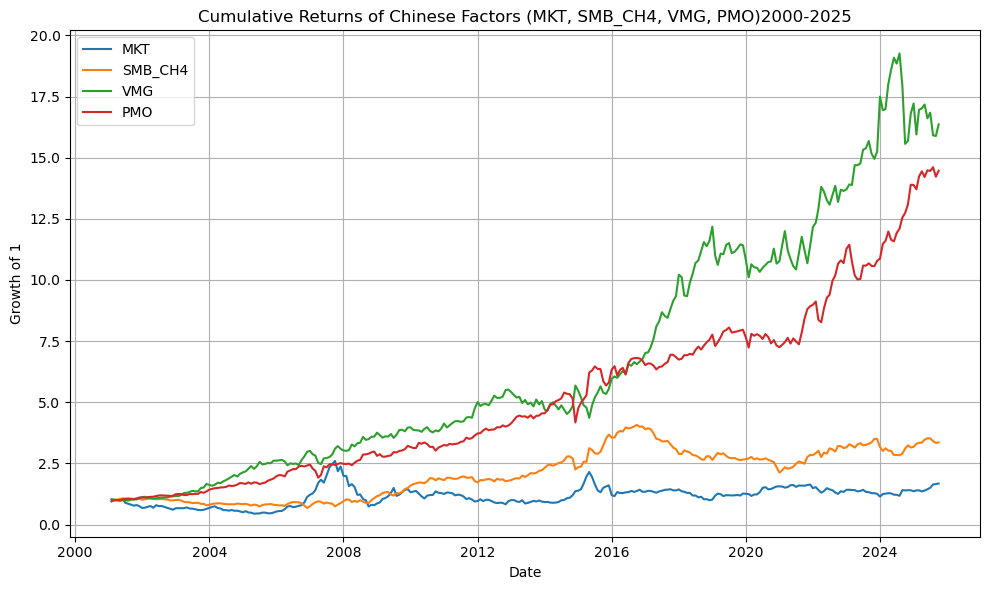

In [57]:

# ---------- 5. 绘制四个因子的累计收益曲线（全样本） ----------

plot_factors = factors[['MKT', 'SMB_CH4', 'VMG', 'PMO']].dropna()

# 累计收益 = ∏(1 + r_t)
cumrets = (1 + plot_factors).cumprod()

plt.figure(figsize=(10, 6))
for col in cumrets.columns:
    plt.plot(cumrets.index, cumrets[col], label=col)

plt.legend()
plt.title("Cumulative Returns of Chinese Factors (MKT, SMB_CH4, VMG, PMO)2000-2025")
plt.xlabel("Date")
plt.ylabel("Growth of 1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
print('SUMMARY')
print("\n===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2016=====")
print(result_old)
print("\n===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2025=====")
print(result_new)

SUMMARY

===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2016=====
             Mean       Std    t-stat       MKT   SMB_CH4       VMG       PMO
MKT      0.599849  8.187019  1.043912  1.000000  0.118522 -0.258383 -0.196269
SMB_CH4  0.845556  4.843546  2.412656  0.118522  1.000000 -0.662259  0.090933
VMG      1.059593  3.802401  3.911238 -0.258383 -0.662259  1.000000 -0.036398
PMO      1.069709  3.724871  3.968908 -0.196269  0.090933 -0.036398  1.000000

===== 四因子总结 (MKT, SMB_CH4, VMG, PMO) 2000~2025=====
             Mean       Std    t-stat       MKT   SMB_CH4       VMG       PMO
MKT      0.505971  7.208257  1.233884  1.000000  0.117437 -0.273526 -0.143728
SMB_CH4  0.508346  4.486692  1.952591  0.117437  1.000000 -0.576785  0.102201
VMG      1.012964  3.962331  4.450048 -0.273526 -0.576785  1.000000 -0.005035
PMO      0.963047  3.453801  4.805387 -0.143728  0.102201 -0.005035  1.000000
